# Julia notebook to experiment with Peterson & Callies (2025, in review) theory.

twnh Sep '23

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\frac{\partial }{\partial z} \left(\kappa(z)  \frac{db}{dz} \right)
    + B(z) & = 0 , \\
\frac{\partial }{\partial z} \left(\kappa_0 + \exp \left( - \alpha (z + H ) \right)  \frac{db}{dz} \right)
    + B(z) & = 0 , \\
\left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 b}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{db}{dz}
    + B(z) & = 0 ,
\end{align}
for $b(z)$, given forcing function $B(z)$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= \beta \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 .
\end{align}

### Approach: Solve the Green's function problem first:

\begin{equation}
0 = \left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 G}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{d G}{dz}
    + \delta(z - \xi) ,
\end{equation}
for $G(z; \xi)$ with boundary conditions
\begin{align}
 \left. \frac{dG}{dz} \right|_{z = -H} = 0 , \\
 G(0; \xi) = 0.
\end{align}
The ODE can be rearranged as:
\begin{equation}
0 = \frac{d }{dz} \left[ 
    \kappa(z) \frac{d G}{dz} \right]
    + \delta(z - \xi) ,
\end{equation}
for $\kappa = \kappa_0 + \exp \left( -\alpha(z + H) \right)$.


### Solution:

Construct $G(z; \xi)$ either side of the point $\xi$:

1. Solve for $G_- (z)$ on $-H \le z \le \xi$, such that

\begin{equation}
\frac{d }{dz} \left[ \kappa(z) \frac{d G_-}{dz} \right] = 0,
\end{equation}

with boundary condition

\begin{equation}
 \left. \frac{dG_-}{dz} \right|_{z = -H} = 0 ,
\end{equation}

where 
\begin{equation}
\kappa(z) = \kappa_0 + \exp \left( - \alpha (z + H) \right) .
\end{equation}

2. Solve for $G_+ (z)$ on $\xi \le z \le 0$, such that

\begin{equation}
\frac{d }{dz} \left[ \kappa(z) \frac{d G_+}{dz} \right] = 0,
\end{equation}

with boundary condition

\begin{equation}
 G_+ (0) = 0 .
\end{equation}

3. Compute the Wronskian of $G_-(z)$ and $G_+(z)$:

\begin{equation}
W(z) = \left| 
\begin{matrix} 
G_-(z) & G_+ (z) \\
G_-'(z) & G_+' (z) 
\end{matrix} \right| .
\end{equation}

4. Write the Green's function as

\begin{align}
G(z; \xi) = \begin{cases}
\displaystyle \frac{G_-(z) G_+(\xi)}{\kappa (\xi) W(\xi)} &\text{\normalsize~~for~} -H \le z \le \xi \\
\displaystyle \frac{G_+(z) G_-(\xi)}{\kappa (\xi) W(\xi)} &\text{\normalsize~~for~} \xi \le z \le 0 
\end{cases} .
\end{align}


5. Solve the original problem using $G(z; \xi)$:

\begin{equation}
b(z) = \int_{-H}^{0} G(z; \xi) B(\xi) \; d \xi  + \beta G(z,-H) .
\end{equation}

In [1]:
using SymPy

Define symbols and functions

In [2]:
κ₀, α, H = symbols("κ₀ α H", real=true, positive=true)
z, ξ, A  = symbols("z ξ A",    real=true)
b        = symbols("b", cls=SymFunction)
B        = symbols("B", cls=SymFunction)
κ(ξ)     = κ₀ + exp(-α*(ξ+H))

# Test with constant diffusivity first: 
# κ(ξ) = κ₀ 
nothing

Define the ODE:

In [3]:
ode = Eq(κ(z) * diff(b(z),z), A)

/      -α*(H + z)\ d           
\κ₀ + e          /*--(b(z)) = A
                   dz          

1. Solve for $G_- (z)$ on $-H \le z \le \xi$, such that

\begin{equation}
\frac{d }{dz} \left[ \kappa(z) \frac{d G_-}{dz} \right] = 0,
\end{equation}

with boundary condition

\begin{equation}
 \left. \frac{dG_-}{dz} \right|_{z = -H} = 0 ,
\end{equation}


In [4]:
bm = dsolve(ode.subs(A,0), b(z)).rhs
# tmp = ode.subs(A,0)
# bm = dsolve(tmp, b(z)).rhs
display(bm)

C1

2. Solve for $\xi \le z \le 0$

In [5]:
bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
display(bp)

       /     -H*α\        /        -H*α\
       |    e    |        | z*α   e    |
  A*log|1 + -----|   A*log|e    + -----|
       \     κ₀  /        \        κ₀  /
- ---------------- + -------------------
        α*κ₀                α*κ₀        

3. Compute Wronskian $W(z)$:

In [6]:
W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

       α*(H + z) 
 A*C1*e          
-----------------
    α*(H + z)    
κ₀*e          + 1

4. Compute Green's function $G(z; \xi)$:

See Zwillinger (1992) page 270 for this formula. It emerges from the requirements that $G$ is continuous at $z=\xi$ and that the derivative jumps by a known amount. These conditions fix the integration constants in $G_-$ and $G_+$.

In [7]:
Gm = simplify(bm * bp.subs(z,ξ) / (κ(ξ) * W.subs(z,ξ)))
Gp = simplify(bm.subs(z,ξ) * bp / (κ(ξ) * W.subs(z,ξ)))

# Check continuity and jump condition:
@assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
@assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ(ξ) == 0

# Define piecewise Green's function:
G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

/     /    H*α    \      /    α*(H + ξ)    \            
|- log\κ₀*e    + 1/ + log\κ₀*e          + 1/            
|-------------------------------------------  for z <= ξ
|                   α*κ₀                                
<                                                       
|     /    H*α    \      /    α*(H + z)    \            
|- log\κ₀*e    + 1/ + log\κ₀*e          + 1/            
|-------------------------------------------  for z >= ξ
\                   α*κ₀                                

Make plot of Green's function for sample parameters

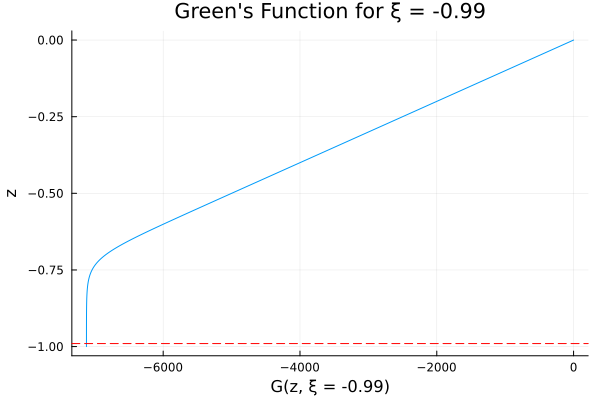

In [8]:
using Plots

# Pick the value of ξ in [-H, 0]:
ξᵢ = -0.99     
# Insert parameter values here and convert symbolic G to a function:
G_fixed(zᵢ,ξᵢ) = G.subs([(κ₀, 0.0001), (α, 32), (H, 1.0), (ξ, ξᵢ), (z, zᵢ)])

# --- Plot ---
zvals = range(-1, 0, length=512)
Gvals = [G_fixed(z_, ξᵢ) |> float for z_ in zvals]  # use float() to get a number
plot(Gvals, zvals, ylabel="z", xlabel="G(z, ξ = $ξᵢ)", title="Green's Function for ξ = $ξᵢ", legend=false)
hline!([ξᵢ], label="ξ", linestyle=:dash, color=:red)